In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.compose import ColumnTransformer 
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import make_pipeline, Pipeline 
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer 
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    ConfusionMatrixDisplay,
)
from sklearn import set_config

### Import the data

In [2]:
df = pd.read_csv('../data/hiv_preprocessed_data.csv')
df.head()

,age,marital_status,std,educational_background,hiv_test_in_past_year,aids_education,places_of_seeking_sex_partners,sexual_orientation,drug_taking,result
0,22,unmarried,no,college degree,yes,no,bar,heterosexual,yes,positive
1,20,unmarried,no,college degree,no,yes,NaN,heterosexual,no,negative
2,23,married,yes,college degree,no,yes,NaN,bisexual,no,negative
3,24,married,no,college degree,yes,yes,park,heterosexual,yes,positive
4,18,unmarried,yes,senior high school,yes,no,internet,heterosexual,yes,positive


In [3]:
mapped = {
    "positive" : 0,
    "negative" : 1 
}

df['result'] = df['result'].map(mapped)

In [4]:
df.isnull().sum()

age                                0
marital_status                     0
std                                0
educational_background             0
hiv_test_in_past_year              0
aids_education                     0
places_of_seeking_sex_partners    11
sexual_orientation                 0
drug_taking                        0
result                             0
dtype: int64

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 10 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   age                             349 non-null    int64
 1   marital_status                  349 non-null    str  
 2   std                             349 non-null    str  
 3   educational_background          349 non-null    str  
 4   hiv_test_in_past_year           349 non-null    str  
 5   aids_education                  349 non-null    str  
 6   places_of_seeking_sex_partners  338 non-null    str  
 7   sexual_orientation              349 non-null    str  
 8   drug_taking                     349 non-null    str  
 9   result                          349 non-null    int64
dtypes: int64(2), str(8)
memory usage: 44.4 KB


In [6]:
x = df.drop(columns = ['result']  )
y = df['result']

X_train, X_test,Y_train,Y_test = train_test_split(x,y , test_size = 0.2, random_state= 42, stratify = y)

In [7]:
print(X_train.shape,
X_test.shape,
Y_train.shape,
Y_test.shape , sep='\n')

(279, 9)
(70, 9)
(279,)
(70,)


In [8]:
Y_train.value_counts(normalize=True)

result
1    0.505376
0    0.494624
Name: proportion, dtype: float64

In [9]:
Y_test.value_counts(normalize=True)

result
1    0.5
0    0.5
Name: proportion, dtype: float64

### Define the categorical variable

In [10]:
cat_col = df.drop(columns=['age','result']).columns.tolist()
num_col = ['age']

In [11]:
num_preprocessor =  make_pipeline(
    SimpleImputer(strategy='median')
)

categorical_preprocessor = Pipeline([
    ('imputer' , SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(sparse_output=False , drop='if_binary'))
])


preprocessor =  ColumnTransformer(
    transformers =[
        ('num_encoder', num_preprocessor,num_col),
       ( 'cat_encoder',categorical_preprocessor, cat_col ),
       

    ],
    remainder='passthrough',
    verbose_feature_names_out=False,
)

### Define utility functions and tables

In [12]:
def get_errors(model, X, y):
    """Computes the error metrics for evaluating a classification model."""

    preds = model.predict(X)
    accuracy = accuracy_score(y, preds)
    recall = recall_score(y, preds)
    precision = precision_score(y, preds, zero_division=0.0)
    return {"accuracy": accuracy, "recall": recall, "precision": precision}


def get_avg_cv_errors(cv_result):
    """Get the average value of the error metrics from the cross validation result."""

    return {
        "accuracy": cv_result["test_accuracy"].mean(),
        "recall": cv_result["test_recall"].mean(),
        "precision": cv_result["test_precision"].mean(),
    }


def plot_confusion_matrix(model, model_name, X, y, split="test"):
    """Plot the confusion matrix of a classification model."""

    ConfusionMatrixDisplay.from_estimator(model, X, y)
    plt.title(f"Confusion Matrix of {model_name} Model [{split.title()} Set]")


def log_error(model_name, errors, eval_set, perf_df):
    """Store the performance metrics of a model."""

    cols = [eval_set + "_" + err for err in ("accuracy", "recall", "precision")]
    perf_df.loc[model_name, cols] = list(errors)

In [13]:
perf_df = pd.DataFrame(
    columns=[
        "train_accuracy",
        "train_recall",
        "train_precision",
        "cv_accuracy",
        "cv_recall",
        "cv_precision",
        "test_accuracy",
        "test_recall",
        "test_precision"
    ]
)

In [14]:
perf_df

,train_accuracy,train_recall,train_precision,cv_accuracy,cv_recall,cv_precision,test_accuracy,test_recall,test_precision


### Build and Evaluate Baseline Model

In [15]:
base_model = DummyClassifier()  
base_model.fit(X_train, Y_train)  

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'prior'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None


In [16]:
train_pred = base_model.predict(X_train)  

In [17]:
train_pred[:10]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [18]:
base_train_errors = get_errors(base_model, X_train, Y_train)
base_train_errors

{'accuracy': 0.5053763440860215,
 'recall': 1.0,
 'precision': 0.5053763440860215}

#### Get cross validation error

In [19]:
cv_results = cross_validate(base_model, X_train, Y_train, cv=5, scoring=get_errors)

In [20]:
cv_results

{'fit_time': array([0.00456429, 0.00194693, 0.00416827, 0.00260925, 0.00200462]),
 'score_time': array([0.01109409, 0.01228976, 0.00867128, 0.00400996, 0.00601554]),
 'test_accuracy': array([0.51785714, 0.5       , 0.5       , 0.5       , 0.50909091]),
 'test_recall': array([1., 1., 1., 1., 1.]),
 'test_precision': array([0.51785714, 0.5       , 0.5       , 0.5       , 0.50909091])}

In [21]:
base_avg_cv_errors = get_avg_cv_errors(cv_results)
base_avg_cv_errors

{'accuracy': np.float64(0.5053896103896104),
 'recall': np.float64(1.0),
 'precision': np.float64(0.5053896103896104)}

In [22]:
log_error("Base Model", base_avg_cv_errors.values(), "cv", perf_df)

In [23]:
perf_df

,train_accuracy,train_recall,train_precision,cv_accuracy,cv_recall,cv_precision,test_accuracy,test_recall,test_precision
Base Model,NaN,NaN,NaN,0.50539,1.0,0.50539,NaN,NaN,NaN


In [24]:
log_error("Base Model", base_train_errors.values(), "train", perf_df)

#### Evaluate model on test set

In [25]:
test_pred = base_model.predict(X_test)

In [26]:
base_test_errors = get_errors(base_model, X_test, Y_test)
base_test_errors

{'accuracy': 0.5, 'recall': 1.0, 'precision': 0.5}

#### Save base model error

In [27]:
log_error("Base Model", base_test_errors.values(), "test", perf_df)

In [28]:
perf_df

,train_accuracy,train_recall,train_precision,cv_accuracy,cv_recall,cv_precision,test_accuracy,test_recall,test_precision
Base Model,0.505376,1.0,0.505376,0.50539,1.0,0.50539,0.5,1.0,0.5


### Plot base model confusion matrix

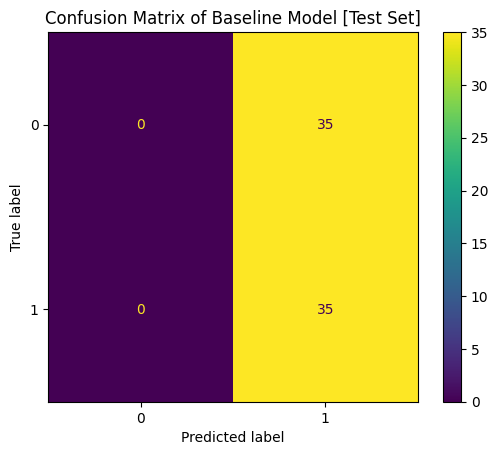

In [29]:
plot_confusion_matrix(base_model, "Baseline", X_test, Y_test)

### Build and Evaluate Logistic Regression Model

In [30]:
lg_model = LogisticRegression(max_iter=200)

In [31]:
lg_pipeline = make_pipeline(preprocessor, lg_model)

Train the model

In [32]:
lg_pipeline.fit(X_train, Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_encoder', ...), ('cat_encoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If th

Evaluate the model

In [33]:
train_preds = lg_pipeline.predict(X_train)

In [34]:
lg_train_errors = get_errors(lg_pipeline, X_train, Y_train)
lg_train_errors

{'accuracy': 0.8136200716845878,
 'recall': 0.8156028368794326,
 'precision': 0.8156028368794326}

Get cross validation result

In [35]:
lg_cv_results = cross_validate(lg_pipeline, X_train, Y_train, cv=5, scoring=get_errors)

In [36]:
lg_avg_cv_errors = get_avg_cv_errors(lg_cv_results)
lg_avg_cv_errors

{'accuracy': np.float64(0.7773376623376622),
 'recall': np.float64(0.8012315270935961),
 'precision': np.float64(0.7752351836792065)}

In [37]:
lg_test_errors = get_errors(lg_pipeline, X_test, Y_test)
lg_test_errors

{'accuracy': 0.6857142857142857,
 'recall': 0.6285714285714286,
 'precision': 0.7096774193548387}

#### Log errors

In [38]:
log_error("Lg_Model", lg_train_errors.values(), "train", perf_df)
log_error("Lg_Model", lg_avg_cv_errors.values(), "cv", perf_df)
log_error("Lg_Model", lg_test_errors.values(), "test", perf_df)

In [39]:
perf_df

,train_accuracy,train_recall,train_precision,cv_accuracy,cv_recall,cv_precision,test_accuracy,test_recall,test_precision
Base Model,0.505376,1.0,0.505376,0.50539,1.0,0.50539,0.5,1.0,0.5
Lg_Model,0.81362,0.815603,0.815603,0.777338,0.801232,0.775235,0.685714,0.628571,0.709677


### Plot LG model confusion matrix

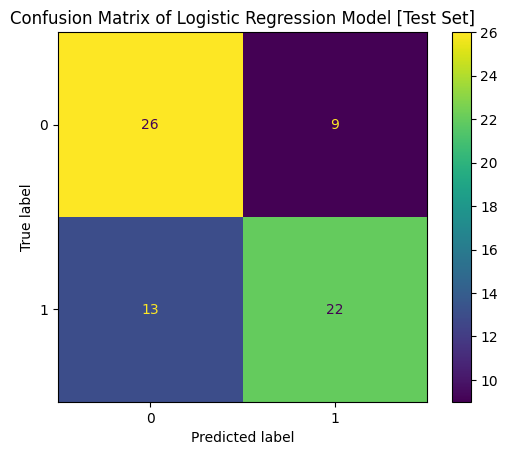

In [40]:
plot_confusion_matrix(lg_pipeline, "Logistic Regression", X_test, Y_test)

### Build and Evaluate Decision Tree Model

In [41]:
dt_model = DecisionTreeClassifier(random_state=42)

In [42]:
dt_pipeline = make_pipeline(preprocessor, dt_model)
dt_pipeline.fit(X_train, Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('decisiontreeclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_encoder', ...), ('cat_encoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3I

#### Handle the overfitting issue in the decision tree

In [43]:
# Check the tree's depth

dt_pipeline[-1].get_depth()

10

#### Find the optimal tree depth with grid search cv

In [44]:
param_grid = {"decisiontreeclassifier__max_depth": range(2, 10)}

grid_search_cv = GridSearchCV(
    dt_pipeline, param_grid=param_grid,
    scoring=["accuracy", "recall", "precision"], refit="recall",
    return_train_score=True
)
grid_search_cv.fit(X_train, Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'decisiontreeclassifier__max_depth': range(2, 10)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'recall', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'recall'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the sco

In [45]:
cv_results = pd.DataFrame(grid_search_cv.cv_results_)
cv_results.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_decisiontreeclassifier__max_depth,params,split0_test_accuracy,split1_test_accuracy,split2_test_accuracy,split3_test_accuracy,...,mean_test_precision,std_test_precision,rank_test_precision,split0_train_precision,split1_train_precision,split2_train_precision,split3_train_precision,split4_train_precision,mean_train_precision,std_train_precision
0,0.031599,0.012937,0.044231,0.044723,2,{'decisiontreeclassifier__max_depth': 2},0.696429,0.821429,0.785714,0.803571,...,0.773166,0.085698,1,0.790476,0.739130,0.752212,0.745614,0.788991,0.763285,0.021993
1,0.036582,0.019672,0.028256,0.022168,3,{'decisiontreeclassifier__max_depth': 3},0.678571,0.821429,0.732143,0.732143,...,0.725418,0.079102,2,0.798246,0.801980,0.778761,0.792453,0.848485,0.803985,0.023607
2,0.019881,0.008542,0.020680,0.002816,4,{'decisiontreeclassifier__max_depth': 4},0.678571,0.839286,0.714286,0.732143,...,0.701022,0.089704,3,0.796610,0.785124,0.815789,0.775194,0.864865,0.807516,0.031694
3,0.025965,0.006036,0.014853,0.007731,5,{'decisiontreeclassifier__max_depth': 5},0.660714,0.696429,0.732143,0.750000,...,0.676332,0.061282,7,0.816000,0.931818,0.811024,0.809524,0.860656,0.845804,0.046975
4,0.031011,0.007783,0.017109,0.009130,6,{'decisiontreeclassifier__max_depth': 6},0.625000,0.767857,0.714286,0.732143,...,0.687297,0.074260,5,0.893805,0.909091,0.891667,0.889908,0.905172,0.897929,0.007715


In [46]:
cv_cols = [
    "param_decisiontreeclassifier__max_depth",
    "mean_test_recall",
    "mean_test_accuracy",
    "mean_test_precision",
    "std_test_recall",
    "mean_train_recall",
    "std_train_recall",
    "rank_test_recall",
    "mean_train_accuracy",
    "mean_train_precision",
]

In [47]:
cv_results_subset = cv_results[cv_cols].sort_values(["rank_test_recall", "std_test_recall"])

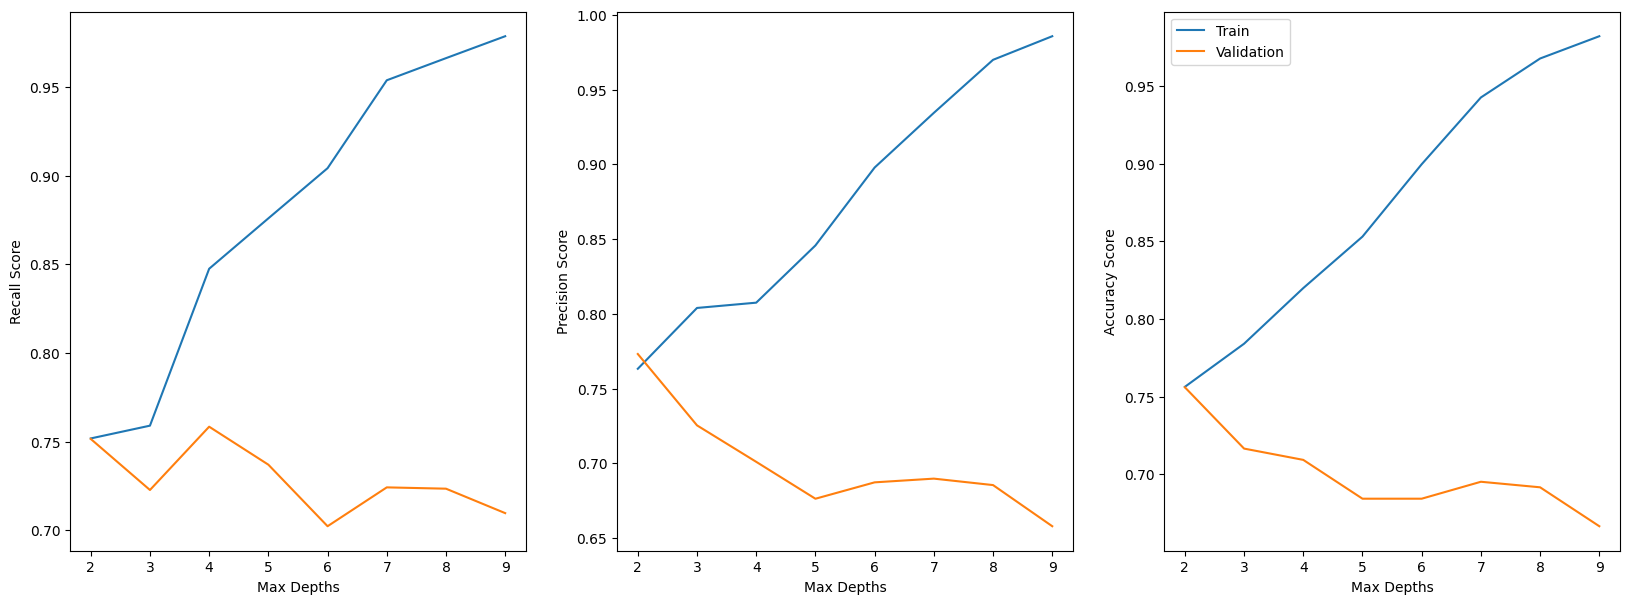

In [48]:
_, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 7))

ax1.plot(cv_results["param_decisiontreeclassifier__max_depth"], cv_results["mean_train_recall"], label="Train")
ax1.plot(cv_results["param_decisiontreeclassifier__max_depth"], cv_results["mean_test_recall"], label="Validation")
ax1.set_xlabel("Max Depths")
ax1.set_ylabel("Recall Score")

ax2.plot(cv_results["param_decisiontreeclassifier__max_depth"], cv_results["mean_train_precision"], label="Train")
ax2.plot(cv_results["param_decisiontreeclassifier__max_depth"], cv_results["mean_test_precision"], label="Validation")
ax2.set_xlabel("Max Depths")
ax2.set_ylabel("Precision Score")

ax3.plot(cv_results["param_decisiontreeclassifier__max_depth"], cv_results["mean_train_accuracy"], label="Train")
ax3.plot(cv_results["param_decisiontreeclassifier__max_depth"], cv_results["mean_test_accuracy"], label="Validation")
ax3.set_xlabel("Max Depths")
ax3.set_ylabel("Accuracy Score")
plt.legend();

In [49]:
cv_results_subset.set_index("param_decisiontreeclassifier__max_depth").loc[[3,4,5]]

,mean_test_recall,mean_test_accuracy,mean_test_precision,std_test_recall,mean_train_recall,std_train_recall,rank_test_recall,mean_train_accuracy,mean_train_precision
param_decisiontreeclassifier__max_depth,,,,,,,,,
3,0.722660,0.716494,0.725418,0.098184,0.758960,0.033231,6,0.784033,0.803985
4,0.758374,0.709221,0.701022,0.070430,0.847503,0.020594,1,0.819859,0.807516
5,0.736946,0.684221,0.676332,0.093202,0.875948,0.075641,3,0.853015,0.845804


We choose the best max depth as 3 because it is optimal for both accuracy and precision at that point. If we choose the max depth for the best average recall on the validation set, we would the be overfitting the other metrics.

In [50]:
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)

In [51]:
# Create pipeline

dt_pipeline = make_pipeline(preprocessor, dt_model)
dt_pipeline.fit(X_train, Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('decisiontreeclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_encoder', ...), ('cat_encoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3I

#### Evaluate the training set

In [52]:
dt_train_errors = get_errors(dt_pipeline, X_train, Y_train)
dt_train_errors

{'accuracy': 0.7777777777777778,
 'recall': 0.7304964539007093,
 'precision': 0.8110236220472441}

#### Cross validate

In [53]:
cv_results = cross_validate(dt_pipeline, X_train, Y_train, cv=5, scoring=["accuracy", "recall", "precision"], n_jobs=-1)
dt_avg_cv_errors = get_avg_cv_errors(cv_results)
dt_avg_cv_errors

{'accuracy': np.float64(0.7164935064935065),
 'recall': np.float64(0.7226600985221674),
 'precision': np.float64(0.7254177219619016)}

#### Evaluate on test

In [54]:
dt_test_errors = get_errors(dt_pipeline, X_test, Y_test)
dt_test_errors

{'accuracy': 0.6428571428571429,
 'recall': 0.5428571428571428,
 'precision': 0.6785714285714286}

In [55]:
log_error("DT Model", dt_train_errors.values(), "train", perf_df)
log_error("DT Model", dt_avg_cv_errors.values(), "cv", perf_df)
log_error("DT Model", dt_test_errors.values(), "test", perf_df)

In [56]:
perf_df

,train_accuracy,train_recall,train_precision,cv_accuracy,cv_recall,cv_precision,test_accuracy,test_recall,test_precision
Base Model,0.505376,1.0,0.505376,0.50539,1.0,0.50539,0.5,1.0,0.5
Lg_Model,0.81362,0.815603,0.815603,0.777338,0.801232,0.775235,0.685714,0.628571,0.709677
DT Model,0.777778,0.730496,0.811024,0.716494,0.72266,0.725418,0.642857,0.542857,0.678571


### Plot DT model confusion matrix

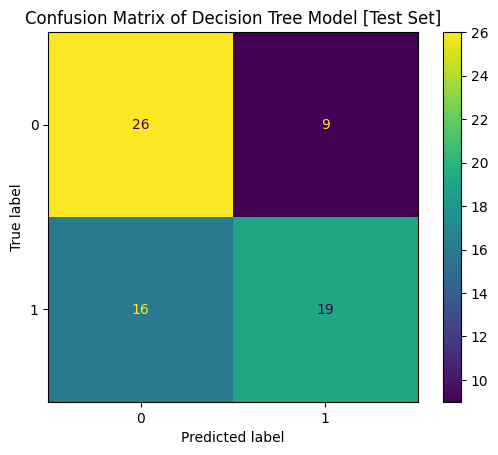

In [57]:
plot_confusion_matrix(dt_pipeline, "Decision Tree", X_test, Y_test)

### Random Forest

In [58]:
rf_model = RandomForestClassifier(max_depth=3, random_state=42)

In [59]:
rf_pipeline = make_pipeline(preprocessor, rf_model)
rf_pipeline.fit(X_train, Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('randomforestclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_encoder', ...), ('cat_encoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3I

#### Evaluate the training set

In [60]:
rf_train_errors = get_errors(rf_pipeline, X_train, Y_train)
rf_train_errors

{'accuracy': 0.8100358422939068,
 'recall': 0.8156028368794326,
 'precision': 0.8098591549295775}

#### Evaluate with cross validation

In [61]:
cv_results = cross_validate(rf_pipeline, X_train, Y_train, scoring=["accuracy", "precision", "recall"], cv=5)
rf_avg_cv_errors = get_avg_cv_errors(cv_results)
rf_avg_cv_errors

{'accuracy': np.float64(0.7485714285714286),
 'recall': np.float64(0.7443349753694581),
 'precision': np.float64(0.75969708994709)}

#### Evaluate on test

In [62]:
rf_test_errors = get_errors(rf_pipeline, X_test, Y_test)
rf_test_errors

{'accuracy': 0.6857142857142857,
 'recall': 0.6,
 'precision': 0.7241379310344828}

### Log Errors

In [63]:
log_error("RF Model", rf_train_errors.values(), "train", perf_df)
log_error("RF Model", rf_avg_cv_errors.values(), "cv", perf_df)
log_error("RF Model", rf_test_errors.values(), "test", perf_df)

In [64]:
perf_df

,train_accuracy,train_recall,train_precision,cv_accuracy,cv_recall,cv_precision,test_accuracy,test_recall,test_precision
Base Model,0.505376,1.0,0.505376,0.50539,1.0,0.50539,0.5,1.0,0.5
Lg_Model,0.81362,0.815603,0.815603,0.777338,0.801232,0.775235,0.685714,0.628571,0.709677
DT Model,0.777778,0.730496,0.811024,0.716494,0.72266,0.725418,0.642857,0.542857,0.678571
RF Model,0.810036,0.815603,0.809859,0.748571,0.744335,0.759697,0.685714,0.6,0.724138


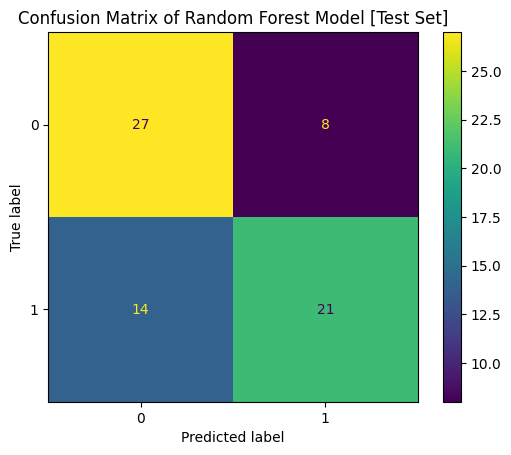

In [65]:
plot_confusion_matrix(rf_pipeline, "Random Forest", X_test, Y_test)

### Gradient Boosting

In [66]:
gb_model = GradientBoostingClassifier(max_depth=3, random_state=42)

In [67]:
gb_pipeline = make_pipeline(preprocessor, gb_model)
gb_pipeline.fit(X_train, Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('gradientboostingclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_encoder', ...), ('cat_encoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=

#### Evaluate the training set

In [68]:
gb_train_errors = get_errors(gb_pipeline, X_train, Y_train)
gb_train_errors

{'accuracy': 0.946236559139785,
 'recall': 0.9574468085106383,
 'precision': 0.9375}

#### Evaluate with cross validation

In [69]:
cv_results = cross_validate(gb_pipeline, X_train, Y_train, scoring=["accuracy", "precision", "recall"], cv=5)
gb_avg_cv_errors = get_avg_cv_errors(cv_results)
gb_avg_cv_errors

{'accuracy': np.float64(0.7164935064935065),
 'recall': np.float64(0.7229064039408868),
 'precision': np.float64(0.7207711213517666)}

#### Evaluate on test

In [70]:
gb_test_errors = get_errors(gb_pipeline, X_test, Y_test)
gb_test_errors

{'accuracy': 0.6428571428571429,
 'recall': 0.5428571428571428,
 'precision': 0.6785714285714286}

In [71]:
log_error("GB Model", gb_train_errors.values(), "train", perf_df)
log_error("GB Model", gb_avg_cv_errors.values(), "cv", perf_df)
log_error("GB Model", gb_test_errors.values(), "test", perf_df)


perf_df

,train_accuracy,train_recall,train_precision,cv_accuracy,cv_recall,cv_precision,test_accuracy,test_recall,test_precision
Base Model,0.505376,1.0,0.505376,0.50539,1.0,0.50539,0.5,1.0,0.5
Lg_Model,0.81362,0.815603,0.815603,0.777338,0.801232,0.775235,0.685714,0.628571,0.709677
DT Model,0.777778,0.730496,0.811024,0.716494,0.72266,0.725418,0.642857,0.542857,0.678571
RF Model,0.810036,0.815603,0.809859,0.748571,0.744335,0.759697,0.685714,0.6,0.724138
GB Model,0.946237,0.957447,0.9375,0.716494,0.722906,0.720771,0.642857,0.542857,0.678571


## Find the optimal learning rate for the GB model

In [72]:
param_grid = {"gradientboostingclassifier__learning_rate": np.linspace(0.01, 0.1, 10), 
              "gradientboostingclassifier__n_estimators": [100,200,300]}

grid_search_cv = GridSearchCV(
    gb_pipeline,
    param_grid=param_grid,
    scoring=["accuracy", "recall", "precision"],
    return_train_score=True,
    refit="recall",
    n_jobs=-1,
)
grid_search_cv.fit(X_train, Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'gradientboostingclassifier__learning_rate': array([0.01, ..., 0.09, 0.1 ]), 'gradientboostingclassifier__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'recall', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'recall'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : t

In [73]:
cv_results = pd.DataFrame(grid_search_cv.cv_results_)

In [74]:
cv_cols = [
    "param_gradientboostingclassifier__learning_rate",
    "param_gradientboostingclassifier__n_estimators",
    "mean_test_recall",
    "mean_test_precision",
    "mean_test_accuracy",
    "mean_train_recall",
    "rank_test_recall",
    "mean_train_accuracy",
    "mean_train_precision",
]
cv_results_subset = cv_results[cv_cols].sort_values(["rank_test_recall"])

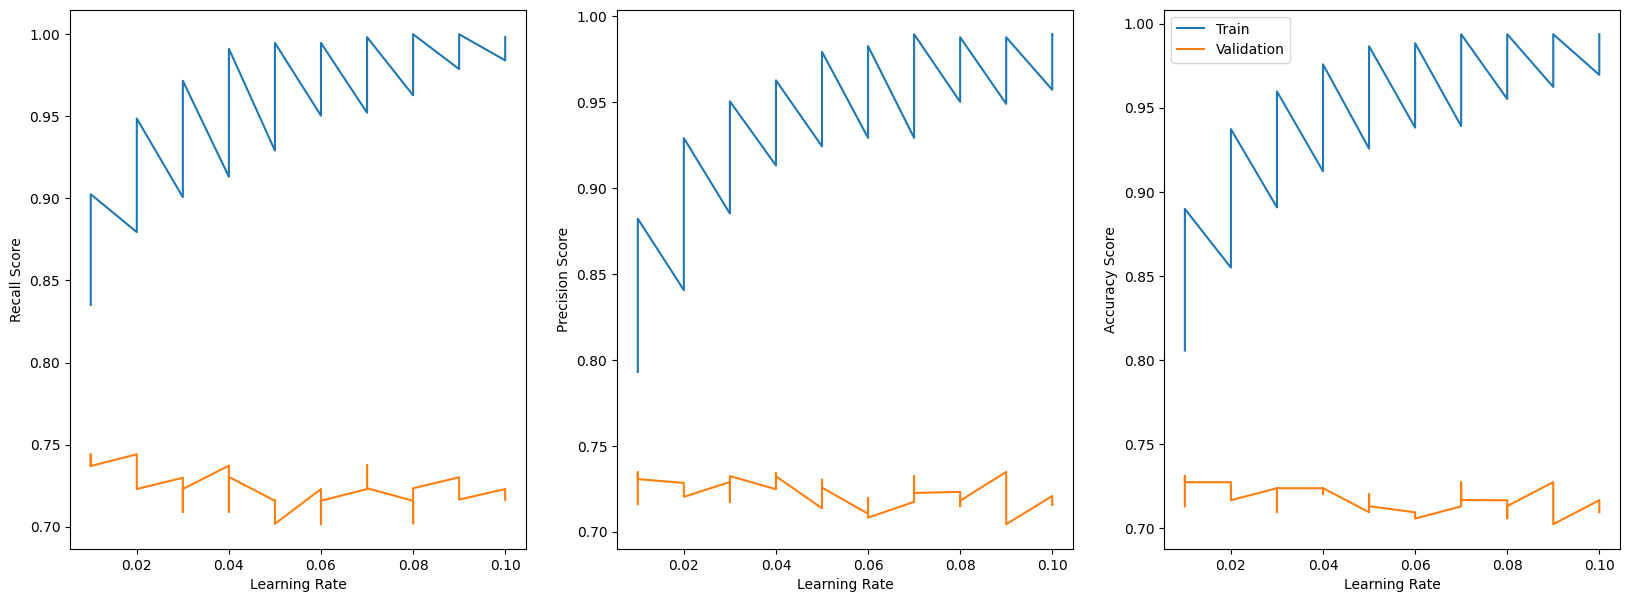

In [75]:
_, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 7))

ax1.plot(cv_results["param_gradientboostingclassifier__learning_rate"], cv_results["mean_train_recall"], label="Train")
ax1.plot(cv_results["param_gradientboostingclassifier__learning_rate"], cv_results["mean_test_recall"], label="Validation")
ax1.set_xlabel("Learning Rate")
ax1.set_ylabel("Recall Score")

ax2.plot(cv_results["param_gradientboostingclassifier__learning_rate"], cv_results["mean_train_precision"], label="Train")
ax2.plot(cv_results["param_gradientboostingclassifier__learning_rate"], cv_results["mean_test_precision"], label="Validation")
ax2.set_xlabel("Learning Rate")
ax2.set_ylabel("Precision Score")

ax3.plot(cv_results["param_gradientboostingclassifier__learning_rate"], cv_results["mean_train_accuracy"], label="Train")
ax3.plot(cv_results["param_gradientboostingclassifier__learning_rate"], cv_results["mean_test_accuracy"], label="Validation")
ax3.set_xlabel("Learning Rate")
ax3.set_ylabel("Accuracy Score")
plt.legend();

In [76]:
cv_results_subset.sort_values("param_gradientboostingclassifier__learning_rate")

,param_gradientboostingclassifier__learning_rate,param_gradientboostingclassifier__n_estimators,mean_test_recall,mean_test_precision,mean_test_accuracy,mean_train_recall,rank_test_recall,mean_train_accuracy,mean_train_precision
1,0.01,200,0.744089,0.734543,0.730779,0.879425,1,0.853944,0.839188
0,0.01,100,0.737192,0.715982,0.712792,0.835098,4,0.805537,0.793001
2,0.01,300,0.736946,0.730605,0.727208,0.902513,6,0.889794,0.882161
3,0.02,100,0.744089,0.728390,0.727208,0.879425,1,0.854841,0.840564
4,0.02,200,0.730049,0.722606,0.720065,0.918473,8,0.913097,0.910280
5,0.02,300,0.722906,0.720295,0.716494,0.948609,14,0.937280,0.929041
6,0.03,100,0.729803,0.728939,0.723636,0.900743,10,0.890691,0.885148
8,0.03,300,0.722906,0.732392,0.723636,0.971650,14,0.959669,0.950426
7,0.03,200,0.708867,0.717264,0.709351,0.946808,26,0.935490,0.927369
9,0.04,100,0.737192,0.724722,0.723636,0.913132,4,0.912192,0.913098


#### Retrain the model with learning rate of 0.01 and n_estimator of 200

In [77]:
gb_model = GradientBoostingClassifier(max_depth=3, learning_rate=0.01, random_state=42 ,n_estimators=200)

In [78]:
retrain_gb_pipeline = make_pipeline(preprocessor, gb_model)
retrain_gb_pipeline.fit(X_train, Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('gradientboostingclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_encoder', ...), ('cat_encoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=

#### Evaluate the training set

In [79]:
gb_train_errors = get_errors(retrain_gb_pipeline, X_train, Y_train)
gb_train_errors

{'accuracy': 0.8207885304659498,
 'recall': 0.8368794326241135,
 'precision': 0.8137931034482758}

#### Evaluate with cross validation

In [80]:
cv_results = cross_validate(retrain_gb_pipeline, X_train, Y_train, scoring=["accuracy", "precision", "recall"], cv=5)
gb_avg_cv_errors = get_avg_cv_errors(cv_results)
gb_avg_cv_errors

{'accuracy': np.float64(0.7307792207792208),
 'recall': np.float64(0.7440886699507389),
 'precision': np.float64(0.7345433876468359)}

#### Evaluate on test

In [81]:
gb_test_errors = get_errors(retrain_gb_pipeline, X_test, Y_test)
gb_test_errors

{'accuracy': 0.6571428571428571,
 'recall': 0.5714285714285714,
 'precision': 0.6896551724137931}

In [82]:
log_error("Opt GB Model", gb_train_errors.values(), "train", perf_df)
log_error("Opt GB Model", gb_avg_cv_errors.values(), "cv", perf_df)
log_error("Opt GB Model", gb_test_errors.values(), "test", perf_df)

perf_df

,train_accuracy,train_recall,train_precision,cv_accuracy,cv_recall,cv_precision,test_accuracy,test_recall,test_precision
Base Model,0.505376,1.0,0.505376,0.50539,1.0,0.50539,0.5,1.0,0.5
Lg_Model,0.81362,0.815603,0.815603,0.777338,0.801232,0.775235,0.685714,0.628571,0.709677
DT Model,0.777778,0.730496,0.811024,0.716494,0.72266,0.725418,0.642857,0.542857,0.678571
RF Model,0.810036,0.815603,0.809859,0.748571,0.744335,0.759697,0.685714,0.6,0.724138
GB Model,0.946237,0.957447,0.9375,0.716494,0.722906,0.720771,0.642857,0.542857,0.678571
Opt GB Model,0.820789,0.836879,0.813793,0.730779,0.744089,0.734543,0.657143,0.571429,0.689655


### Plot optimal GB confusion matrix

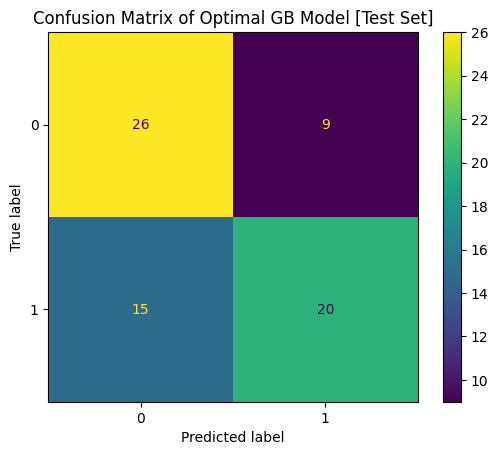

In [83]:
plot_confusion_matrix(retrain_gb_pipeline, "Optimal GB", X_test, Y_test)

#### Add kmeans features to GB model

In [84]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import FeatureUnion

In [85]:
kmean_pipe = make_pipeline(
    preprocessor,
    StandardScaler(),
    KMeans(3, random_state=42)
)

In [86]:
feat_union = FeatureUnion(
    [
        ("base_feat", preprocessor),
        ("kmeans_feat", kmean_pipe),
    ],
    verbose_feature_names_out=False
)

In [87]:
gb_kmeans_pipeline = make_pipeline(
    feat_union,
    gb_model
)

In [88]:
gb_kmeans_pipeline.fit(X_train, Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('featureunion', ...), ('gradientboostingclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformer_list transformer_list: list of (str, transformer) tuplesList of transformer objects to be applied to the data. The firsthalf of each tuple is the name of the transformer. The transformer canbe 'drop' for it to be ignored or can be 'passthrough' for features tobe passed unchanged... versionadded:: 1.1 Added the option `""passthrough""`... versionchanged:: 0.22 Deprecated `None` as a transformer in favor of 'drop'.","[('base_feat', ...), ('kmeans_feat', ...)]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer.Keys are transformer names, values the weights.Raises ValueError if key not present in ``transformer_list``.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, default=TrueIf True, :meth:`get_feature_names_out` will prefix all feature nameswith the name of the transformer that generated that feature.If False, :meth:`get_feature_names_out` will not prefix any featurenames and will error if feature names are not unique... versionadded:: 1.5",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the

In [89]:
gb_train_errors = get_errors(gb_kmeans_pipeline, X_train, Y_train)
gb_train_errors

{'accuracy': 0.8530465949820788,
 'recall': 0.8723404255319149,
 'precision': 0.8424657534246576}

In [90]:
cv_results = cross_validate(gb_kmeans_pipeline, X_train, Y_train, scoring=["accuracy", "precision", "recall"], cv=5, n_jobs=-1)
gb_avg_cv_errors = get_avg_cv_errors(cv_results)
gb_avg_cv_errors

{'accuracy': np.float64(0.7165584415584415),
 'recall': np.float64(0.737192118226601),
 'precision': np.float64(0.7161830065359477)}

In [91]:
gb_test_errors = get_errors(gb_kmeans_pipeline, X_test, Y_test)
gb_test_errors

{'accuracy': 0.6285714285714286,
 'recall': 0.5142857142857142,
 'precision': 0.6666666666666666}

In [92]:
log_error("Opt GB+KM Model", gb_train_errors.values(), "train", perf_df)
log_error("Opt GB+KM Model", gb_avg_cv_errors.values(), "cv", perf_df)
log_error("Opt GB+KM Model", gb_test_errors.values(), "test", perf_df)

perf_df

,train_accuracy,train_recall,train_precision,cv_accuracy,cv_recall,cv_precision,test_accuracy,test_recall,test_precision
Base Model,0.505376,1.0,0.505376,0.50539,1.0,0.50539,0.5,1.0,0.5
Lg_Model,0.81362,0.815603,0.815603,0.777338,0.801232,0.775235,0.685714,0.628571,0.709677
DT Model,0.777778,0.730496,0.811024,0.716494,0.72266,0.725418,0.642857,0.542857,0.678571
RF Model,0.810036,0.815603,0.809859,0.748571,0.744335,0.759697,0.685714,0.6,0.724138
GB Model,0.946237,0.957447,0.9375,0.716494,0.722906,0.720771,0.642857,0.542857,0.678571
Opt GB Model,0.820789,0.836879,0.813793,0.730779,0.744089,0.734543,0.657143,0.571429,0.689655
Opt GB+KM Model,0.853047,0.87234,0.842466,0.716558,0.737192,0.716183,0.628571,0.514286,0.666667


## Plot Confusion Matrix of GB_KM model

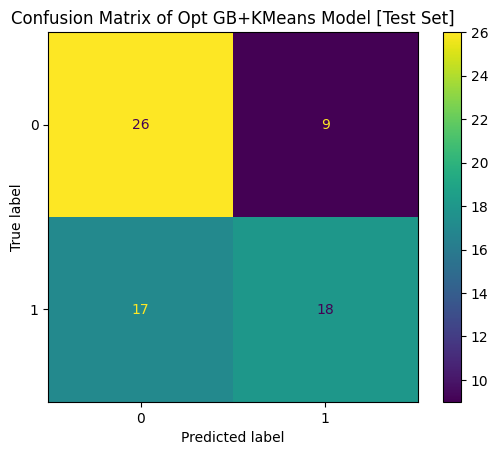

In [93]:
plot_confusion_matrix(gb_kmeans_pipeline, "Opt GB+KMeans", X_test, Y_test)

## Visualize feature importance

In [94]:
feature_names  = gb_kmeans_pipeline[:-1].get_feature_names_out()

In [95]:
feat_imps = pd.Series(
    gb_kmeans_pipeline[-1].feature_importances_,
    index=feature_names
).sort_values()

In [96]:
def clean_feats_name(feature):
    if "__" in feature:
        return feature[feature.index("__")+2:]
    return feature

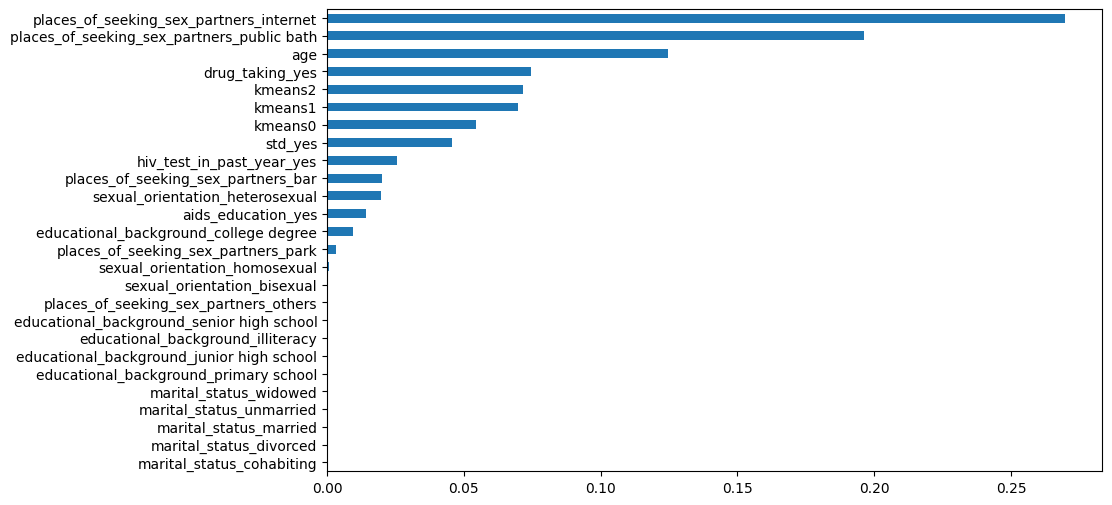

In [97]:
ax = feat_imps.plot(kind="barh", figsize=(10, 6))
ax.set_yticklabels(feat_imps.index.map(clean_feats_name));

## Plot precision recall curve

In [98]:
from sklearn.metrics import precision_recall_curve

In [99]:
precision, recall, thresholds = precision_recall_curve(Y_test, gb_kmeans_pipeline.predict_proba(X_test)[:, 1])

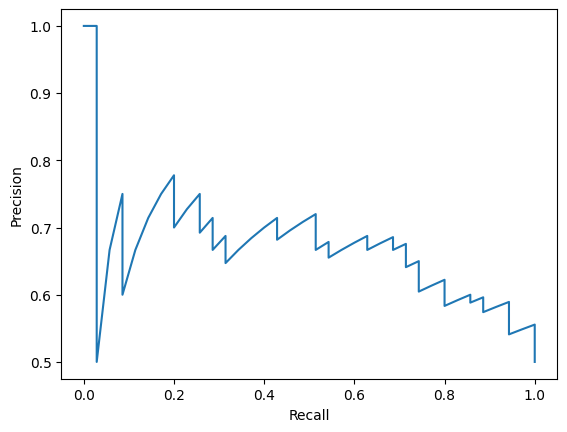

In [100]:
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision");

## Find optimal probability threshold

In [101]:
from sklearn.model_selection import TunedThresholdClassifierCV

In [102]:
ttcv = TunedThresholdClassifierCV(gb_kmeans_pipeline, cv=5, n_jobs=-1)
ttcv.fit(X_train, Y_train)

,"estimator estimator: estimator instanceThe classifier, fitted or not, for which we want to optimizethe decision threshold used during `predict`.",Pipeline(step...m_state=42))])
,"scoring scoring: str or callable, default=""balanced_accuracy""The objective metric to be optimized. Can be one of:- str: string associated to a scoring function for binary classification, see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.",'balanced_accuracy'
,"response_method response_method: {""auto"", ""decision_function"", ""predict_proba""}, default=""auto""Methods by the classifier `estimator` corresponding to thedecision function for which we want to find a threshold. It can be:* if `""auto""`, it will try to invoke, for each classifier, `""predict_proba""` or `""decision_function""` in that order.* otherwise, one of `""predict_proba""` or `""decision_function""`. If the method is not implemented by the classifier, it will raise an error.",'auto'
,"thresholds thresholds: int or array-like, default=100The number of decision threshold to use when discretizing the output of theclassifier `method`. Pass an array-like to manually specify the thresholdsto use.",100
,"cv cv: int, float, cross-validation generator, iterable or ""prefit"", default=NoneDetermines the cross-validation splitting strategy to train classifier.Possible inputs for cv are:* `None`, to use the default 5-fold stratified K-fold cross validation;* An integer number, to specify the number of folds in a stratified k-fold;* A float number, to specify a single shuffle split. The floating number should be in (0, 1) and represent the size of the validation set;* An object to be used as a cross-validation generator;* An iterable yielding train, test splits;* `""prefit""`, to bypass the cross-validation.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... warning:: Using `cv=""prefit""` and passing the same dataset for fitting `estimator` and tuning the cut-off point is subject to undesired overfitting. You can refer to :ref:`TunedThresholdClassifierCV_no_cv` for an example. This option should only be used when the set used to fit `estimator` is different from the one used to tune the cut-off point (by calling :meth:`TunedThresholdClassifierCV.fit`).",5
,"refit refit: bool, default=TrueWhether or not to refit the classifier on the entire training set oncethe decision threshold has been found.Note that forcing `refit=False` on cross-validation having morethan a single split will raise an error. Similarly, `refit=True` inconjunction with `cv=""prefit""` will raise an error.",True
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. When `cv` represents across-validation strategy, the fitting and scoring on each data splitis done in parallel. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of cross-validation when `cv` is a float.See :term:`Glossary `.",None
,"store_cv_results store_cv_results: bool, default=FalseWhether to store all scores and thresholds computed during the cross-validationprocess.",False
,"transformer_list transformer_list: list of (str, transformer) tuplesList of transformer objects to be applied to the data. The firsthalf of each tuple is the name of the transformer. The transformer canbe 'drop' for it to be ignored or can be 'passthrough' for features tobe passed unchanged... versionadded:: 1.1 Added the option `""passthrough""`... versionchanged:: 0.22 Deprecated `None` as a transformer in favor of 'drop'.","[('base_feat', ...), ('kmeans_feat', ...)]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context

In [103]:
ttcv_train_error = get_errors(ttcv, X_train, Y_train)
ttcv_train_error

{'accuracy': 0.8422939068100358,
 'recall': 0.9148936170212766,
 'precision': 0.8012422360248447}

In [104]:
ttcv_results = cross_validate(
    ttcv, X_train, Y_train, scoring=["accuracy", "precision", "recall"], cv=5, n_jobs=-1
)
ttcv_cv_errors = get_avg_cv_errors(cv_results)
ttcv_cv_errors

{'accuracy': np.float64(0.7165584415584415),
 'recall': np.float64(0.737192118226601),
 'precision': np.float64(0.7161830065359477)}

In [105]:
ttcv_test_error = get_errors(ttcv, X_test, Y_test)
ttcv_test_error

{'accuracy': 0.6714285714285714,
 'recall': 0.6571428571428571,
 'precision': 0.6764705882352942}

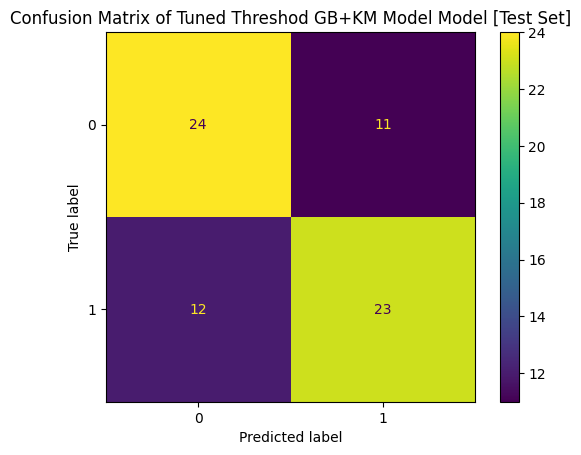

In [106]:
plot_confusion_matrix(
    ttcv, "Tuned Threshod GB+KM Model", X_test, Y_test
)

In [107]:
log_error("Opt GB+KM+TTCV Model", ttcv_train_error.values(), "train", perf_df)
log_error("Opt GB+KM+TTCV Model", ttcv_cv_errors.values(), "cv", perf_df)
log_error("Opt GB+KM+TTCV Model", ttcv_test_error.values(), "test", perf_df)

In [108]:
perf_df

,train_accuracy,train_recall,train_precision,cv_accuracy,cv_recall,cv_precision,test_accuracy,test_recall,test_precision
Base Model,0.505376,1.0,0.505376,0.50539,1.0,0.50539,0.5,1.0,0.5
Lg_Model,0.81362,0.815603,0.815603,0.777338,0.801232,0.775235,0.685714,0.628571,0.709677
DT Model,0.777778,0.730496,0.811024,0.716494,0.72266,0.725418,0.642857,0.542857,0.678571
RF Model,0.810036,0.815603,0.809859,0.748571,0.744335,0.759697,0.685714,0.6,0.724138
GB Model,0.946237,0.957447,0.9375,0.716494,0.722906,0.720771,0.642857,0.542857,0.678571
Opt GB Model,0.820789,0.836879,0.813793,0.730779,0.744089,0.734543,0.657143,0.571429,0.689655
Opt GB+KM Model,0.853047,0.87234,0.842466,0.716558,0.737192,0.716183,0.628571,0.514286,0.666667
Opt GB+KM+TTCV Model,0.842294,0.914894,0.801242,0.716558,0.737192,0.716183,0.671429,0.657143,0.676471


### We are choosing rf model as our final model since it as a more balnace error across all score 

### Retrain the whole dataset

In [109]:
rf_pipeline.fit(x,y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('randomforestclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_encoder', ...), ('cat_encoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3I

In [110]:
get_errors(rf_pipeline,x,y)

{'accuracy': 0.7765042979942693,
 'recall': 0.7670454545454546,
 'precision': 0.7848837209302325}

### save model

In [111]:
import joblib

In [112]:
joblib.dump(rf_pipeline,'../model/Hiv_model_v1.pkl')

['../model/Hiv_model_v1.pkl']

### Load the model and test

In [113]:
model = joblib.load('../model/Hiv_model_v1.pkl')

In [114]:
get_errors(model,x,y)

{'accuracy': 0.7765042979942693,
 'recall': 0.7670454545454546,
 'precision': 0.7848837209302325}